# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Generate Synthetic Dataset

In [2]:
np.random.seed(42)  # reproducibility

n = 500  # number of buildings

# Features
building_types = ['Office', 'School', 'Commercial', 'Hospital']
df = pd.DataFrame({
    'Building_Type': np.random.choice(building_types, n),
    'Square_Feet': np.random.randint(500, 5000, n),
    'Occupancy': np.random.randint(5, 200, n),
    'Appliances': np.random.randint(5, 50, n),
    'Temperature': np.random.randint(18, 28, n)  # Celsius
})

# Encode Building_Type as numeric
df = pd.get_dummies(df, columns=['Building_Type'], drop_first=True)

# Synthetic energy consumption (target) with higher noise and slight non-linearity
df['Energy_Consumption'] = (
    df['Square_Feet'] * 0.45 +
    df['Occupancy'] * 1.8 +
    df['Appliances'] * 4.5 +
    df['Temperature'] * 8 +
    np.random.normal(0, 300, n) +  # increased noise
    0.01 * df['Square_Feet'] * df['Occupancy']  # slight interaction term
)

print("Synthetic dataset preview:")
print(df.head())

Synthetic dataset preview:
   Square_Feet  Occupancy  Appliances  Temperature  Building_Type_Hospital  \
0          690        147          43           27                   False   
1         2800        156          19           26                    True   
2         1480         42           8           18                   False   
3         3475        167          33           22                   False   
4         1684         98          26           21                   False   

   Building_Type_Office  Building_Type_School  Energy_Consumption  
0                 False                 False         2241.578760  
1                 False                 False         5989.164235  
2                  True                 False         1537.695294  
3                 False                 False         8385.635170  
4                 False                 False         2584.903453  


# Exploratory Data Analysis (EDA)


Summary Statistics:
       Square_Feet  Occupancy  Appliances  Temperature  Energy_Consumption
count   500.000000   500.0000  500.000000   500.000000          500.000000
mean   2800.182000   100.3220   27.242000    22.366000         4569.648676
std    1272.026192    55.7961   12.860724     2.853828         2626.722286
min     503.000000     5.0000    5.000000    18.000000          132.294001
25%    1716.250000    50.7500   16.000000    20.000000         2386.517103
50%    2795.000000   101.5000   28.000000    22.000000         3983.094824
75%    3845.750000   150.2500   38.000000    25.000000         6338.840831
max    4995.000000   199.0000   49.000000    27.000000        13112.586701


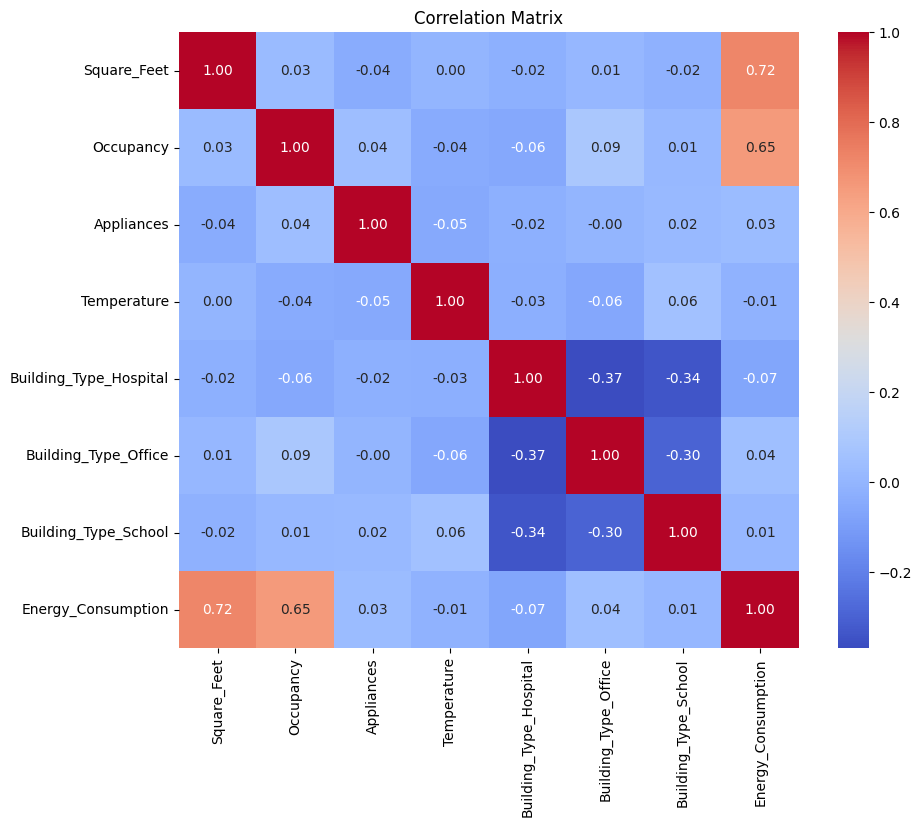

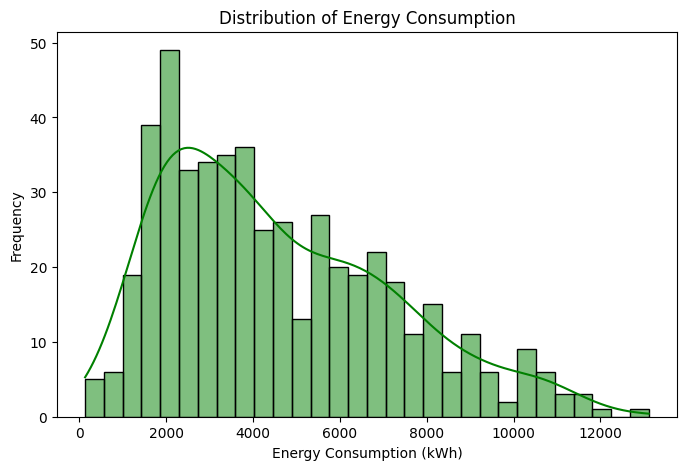

In [3]:
# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Histogram of Energy Consumption
plt.figure(figsize=(8,5))
sns.histplot(df['Energy_Consumption'], bins=30, kde=True, color='green')
plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("Frequency")
plt.show()

# Regression Model (Predict Energy Consumption)

In [4]:
X = df.drop('Energy_Consumption', axis=1)
y = df['Energy_Consumption']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Model Evaluation


Model Evaluation Metrics:
Mean Squared Error (MSE): 644954.96
R² Score: 0.91


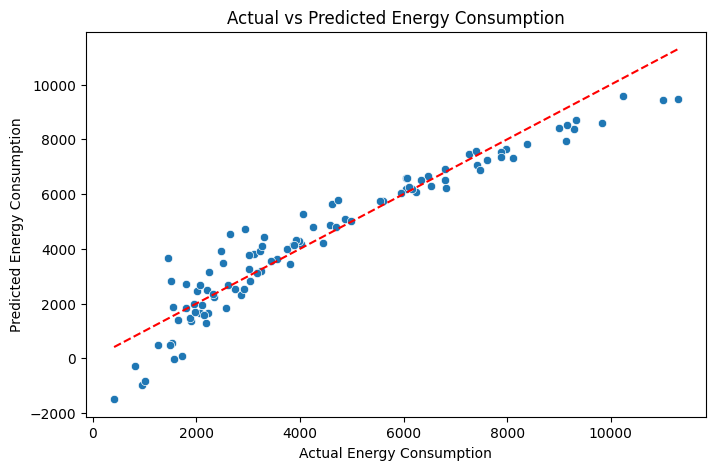

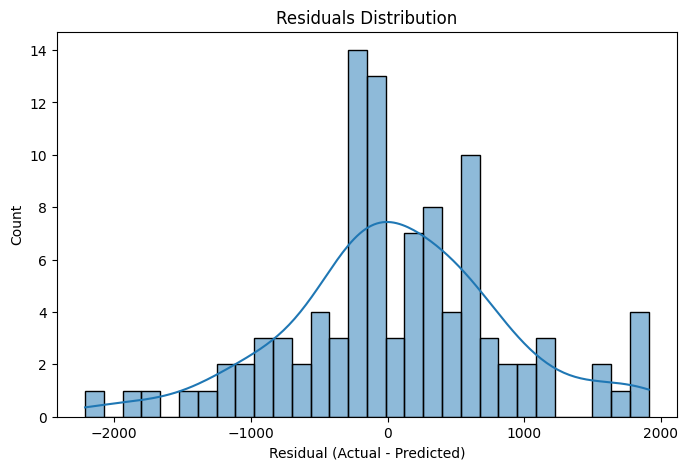

In [5]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")  # should now be realistic (~0.7–0.9)

# Actual vs Predicted scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")
plt.show()

# Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()

# Feature Importance (Linear Regression Coefficients)

In [6]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nFeature Importance:")
print(coefficients)


Feature Importance:
                  Feature  Coefficient
5    Building_Type_Office  -209.363675
4  Building_Type_Hospital   -82.775319
6    Building_Type_School   -70.789565
1               Occupancy    30.263605
3             Temperature    14.211819
2              Appliances     6.543130
0             Square_Feet     1.450042
